# Cash Flow Forecasting

### Prepared by Dr. Omar A. Guerrero

This demo shows how to deploy the XGBoost machine learning algorithm to perform cash flow forecasting using time series data with a daily frequency.

### Data
Total daily deposits in the Treasury General Account of the United States of America. The frequency is daily and the coverage is from 1 January 2022 to 7 July 2026. The units are millions of USD. The source dataset can be downloaded here: https://fiscaldata.treasury.gov/datasets/daily-treasury-statement/deposits-and-withdrawals-of-operating-cash

### Problem
We will train XGBoost for the univariate time series case and forecast daily deposits between 1 January and 7 July 2026.

### Requirements
The code was developed in Python version 3.12. The required libraries that need to be installed are:
- `pandas` (to load and manipulate the data)
- `numpy` (contains useful tools)
- `matplotlib` (to create plots)
- `optuna` (to fine tune the model)
- `xgboost` (provides the model to be trained)
- `u8darts[all]` (provides time series data structures, tools for uncertainty quantification, and an interface for XGBoost that makes fine tuning easier; this interface is the same for other models beyond XGBoost)
- 
## What is XGBoost?

XGBoost is an algorithm to make predictions based on decision trees (see seminal paper: https://doi.org/10.48550/arXiv.1603.02754).

- A decision tree is a flowchart of Yes/No questions that sequentially splits features data to make a prediction about the most likely value of the dependent variable
- XGBoost creates a sequence of decision trees, each tree predicting the residuals left by the previous one
- All trees are combined to make the final prediction
- There are many auxiliary techniques under the hood that makes XGBoost very successful (e.g., tree pruning, gradient computation, regularisation, parallelisation)
- In the context of univariate time series, the features are constructed by the user and they are typically different degrees of lags (i.e., time has no meaning and there is no underlying model)
- XGBoost does not model uncertainty, so additional tools are required to generate confidence intervals (e.g., Monte Carlo simulation)

## A graphical illustration of XGBoost
![alt text](images/xgboost.png)
Image source: Chirag Subramanian (https://www.linkedin.com/posts/chiragsubramanian_xgboost-why-it-still-dominates-ml-on-structured-share-7471546825540296704-l2xf/)

## Could one use other machine learning methods?

Yes, XGBoost is one of many alternative methods that could be used to predict cash flows time series. However, recent work by the IMF comparing different machine learning approaches find that, for the univariate case, XGBoost shows the best balance between predictive accuracy, computational costs, and confidence. The Darts library gives access to a vast selection of machine learning models through a common interface.

## What tools can be used to deploy XGBoost and other models?
![alt text](images/logo_mosaic.png)



## Import libraries

In [1]:
import numpy as np
import pandas as pd
import darts
import optuna
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from darts import TimeSeries
from darts.dataprocessing.transformers import MissingValuesFiller, Scaler
from darts.models import XGBModel
from darts.metrics import rmse
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")


/home/oguerrer/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Start demo!

## Load the data

In [2]:
df = pd.read_csv('US_TGA_deposits.csv')
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d')
series = darts.TimeSeries.from_dataframe(df, 'DATE', 'FLOW', fill_missing_dates=False, freq='D')


## Explore the data

### Entire sample

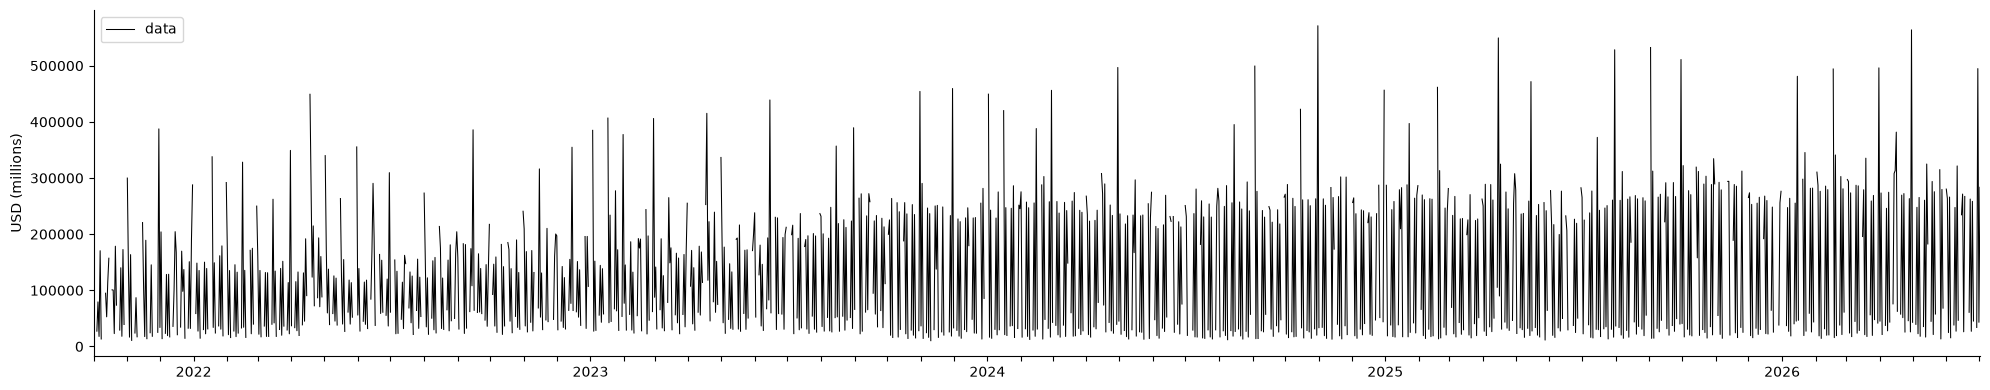

In [3]:
plt.figure(figsize=(20,4))
ax = series.plot(color='k', linewidth=.75, label='data')
plt.gca().spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.legend()
plt.tight_layout()
plt.show()


### Period to be forecasted

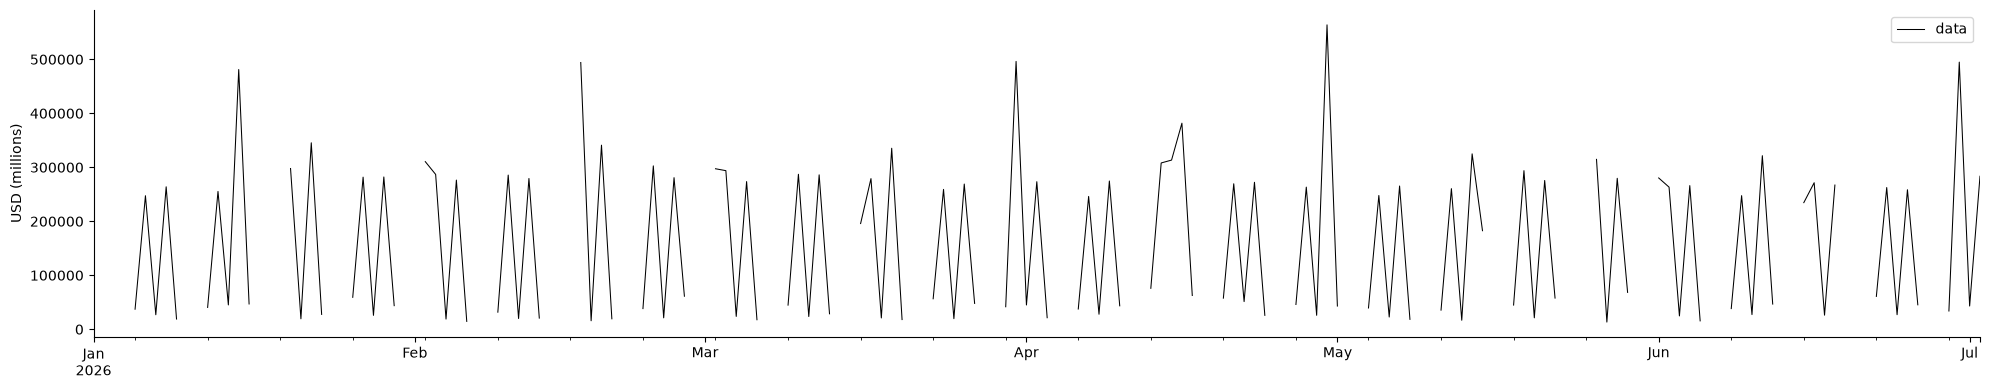

In [4]:
plt.figure(figsize=(20,4))
year_df = series.to_dataframe()
year_df = year_df[year_df.index.year == 2026]
year_ts = TimeSeries.from_dataframe(year_df)
year_ts.plot(color='k', linewidth=.75, label='data')
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Rescale the data

In [5]:
# load Darts scaler and use it to rescale the time series between 0 and 1
scaler = Scaler(global_fit=True)
series_nonans = MissingValuesFiller().transform(series)
series_scaled = scaler.fit_transform(series_nonans)


## Split data for fine tuning

In [6]:
date_cut = '2026-01-01'
date_val = '2025-01-01'

target_date = pd.Timestamp(date_cut)
split_index = series.time_index.get_loc(target_date)
split_point = series_scaled.time_index[split_index]
train, test = series_scaled.split_before(split_point)

target_date = pd.Timestamp(date_val)
split_index_val = series.time_index.get_loc(target_date)
split_point_val = series_scaled.time_index[split_index_val]
train_val, test_val = train.split_before(split_point_val)


## Plot split data

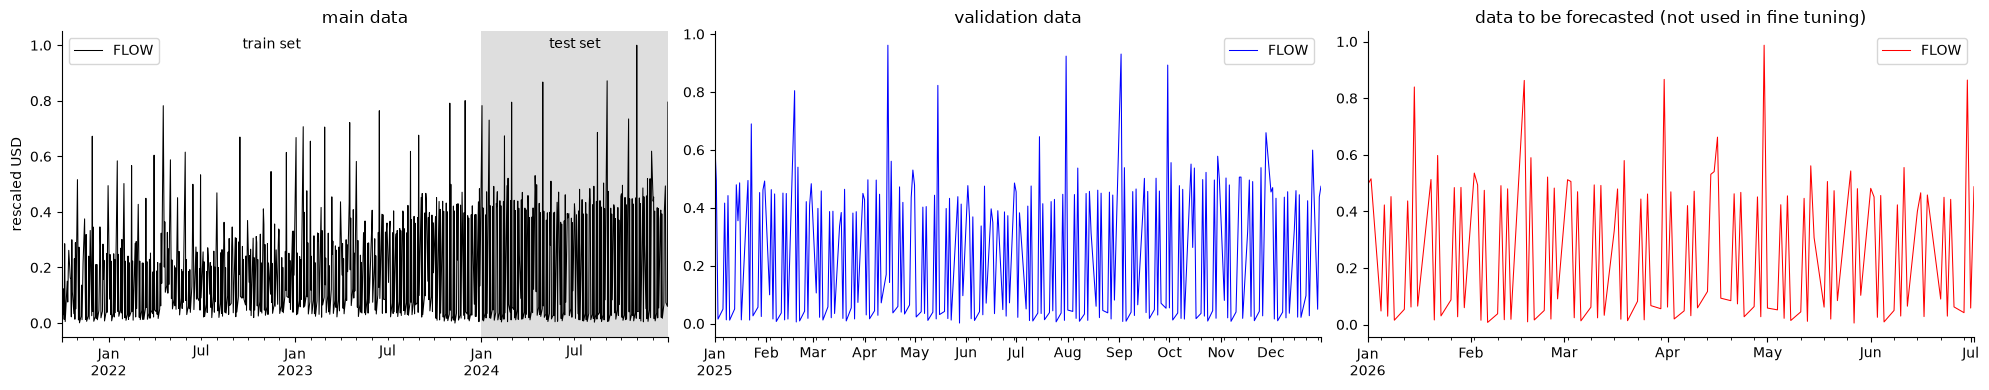

In [7]:
plt.figure(figsize=(20,4))

plt.subplot(131)
ax = train_val.plot(color='k', linewidth=.75)
start = datetime(2024, 1, 1)
xmin, xmax = ax.get_xlim()
start_num = mdates.date2num(start)
ax.axvspan(start, xmax, facecolor='lightgray', alpha=0.75, zorder=-1)
start_norm = (start_num - xmin) / (xmax - xmin)
clear_center_x  = 0.5 * start_norm
shaded_center_x = 0.5 * (start_norm + 1.0)
ax.text(clear_center_x, 0.98, "train set", ha="center", va="top", transform=ax.transAxes)
ax.text(shaded_center_x, 0.98, "test set", ha="center", va="top", transform=ax.transAxes)
plt.title('main data')
plt.ylabel('rescaled USD')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel(None)

plt.subplot(132)
test_val.plot(color='b', linewidth=.75)
plt.title('validation data')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel(None)

plt.subplot(133)
test.plot(color='r', linewidth=.75)
plt.title('data to be forecasted (not used in fine tuning)')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel(None)

plt.tight_layout()
plt.show()


## Fine tuning

In [8]:
SEED = 0
limits = {"lags_lb": 1, "lags_ub": 360, # 
          "max_depth_lb": 3, "max_depth_ub": 9, # how deep should the decision trees be?
          "n_estimators_lb": 10, "n_estimators_ub": 100, # how many trees should be built?
          "learning_rate_lb": 0.001, "learning_rate_ub": 0.5, # at what rate should the weight of each sequential tree drop?
          "min_child_weight_lb": 1.0, "min_child_weight_ub": 10.0, # what is the minimum amount of data needed to create a new branch in a tree?
          "subsample_lb": 0.5, "subsample_ub": 1.0, # what fraction of the training data should be sampled to train a tree?
          "colsample_bytree_lb": 0.5, "colsample_bytree_ub": 1.0, # how many features should be sampled to train a tree?
          "gamma_lb": 0.0, "gamma_ub": 5.0, # regularisation parameter (minimum loss reduction required to make a split in a tree)?
          "n_trials": 25} # number of trainings

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    multivariate=True, # models hyperparameters as a mixture of Gaussians (useful for XGBoost as its hyperparameters are highly interdependent)
    group=True, # makes the multivariate model scalable
    n_startup_trials=50, # initial exploration to build the prior
)

def objective(trial):
    lags = trial.suggest_int("lags", limits["lags_lb"], limits["lags_ub"])
    max_depth = trial.suggest_int("max_depth", limits["max_depth_lb"], limits["max_depth_ub"])
    n_estimators = trial.suggest_int("n_estimators", limits["n_estimators_lb"], limits["n_estimators_ub"])
    learning_rate = trial.suggest_float(
        "learning_rate",
        limits["learning_rate_lb"],
        limits["learning_rate_ub"],
        log=True,
    )

    min_child_weight = trial.suggest_float(
        "min_child_weight",
        limits["min_child_weight_lb"],
        limits["min_child_weight_ub"],
    )
    subsample = trial.suggest_float(
        "subsample",
        limits["subsample_lb"],
        limits["subsample_ub"],
    )
    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        limits["colsample_bytree_lb"],
        limits["colsample_bytree_ub"],
    )
    gamma = trial.suggest_float(
        "gamma",
        limits["gamma_lb"],
        limits["gamma_ub"],
    )

    model = XGBModel(
        random_state=SEED,
        lags=lags,
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        output_chunk_length=1,
        model_kwargs={
            "min_child_weight": min_child_weight,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "gamma": gamma,
        },
    )

    model.fit(
        train_val,
        val_series=test_val,
        verbose=False,
    )

    pred = model.predict(n=len(test_val))

    error = rmse(
        scaler.inverse_transform(test_val),
        scaler.inverse_transform(pred),
    )

    return error


optuna.logging.set_verbosity(optuna.logging.WARNING) # do not print progress (comment to see progress messages)

# run the hyperparameter search algorithm
study = optuna.create_study(direction="minimize", sampler=sampler) # create the object that will explore the hyperparameters
study.optimize(objective, n_trials=limits['n_trials']) # run fine tuning
optimal_pars = study.best_params # save best hyperparameters dictionary

print('Fine tuning is done.')


Fine tuning is done.


## Train and forecast 2026

In [9]:
date_cut = '2026-01-01'
target_date = pd.Timestamp(date_cut)
split_index = series.time_index.get_loc(target_date)
split_point = series_scaled.time_index[split_index]
train, test = series_scaled.split_before(split_point)

model = XGBModel(
    random_state=SEED,
    lags=optimal_pars['lags'],
    max_depth=optimal_pars['max_depth'],
    n_estimators=optimal_pars['n_estimators'],
    learning_rate=optimal_pars['learning_rate'],
    model_kwargs={
        "min_child_weight": optimal_pars['min_child_weight'],
        "subsample": optimal_pars['subsample'],
        "colsample_bytree": optimal_pars['colsample_bytree'],
        "gamma": optimal_pars['gamma'],
    },
)


model.fit(train)#, future_covariates=cov_full)
forecast = model.predict(n=len(test))#, future_covariates=cov_full)
df_forecast = scaler.inverse_transform(forecast).to_dataframe()


print('Model has been trained. Forecast is ready!')


Model has been trained. Forecast is ready!


## Plot forecast of 2026

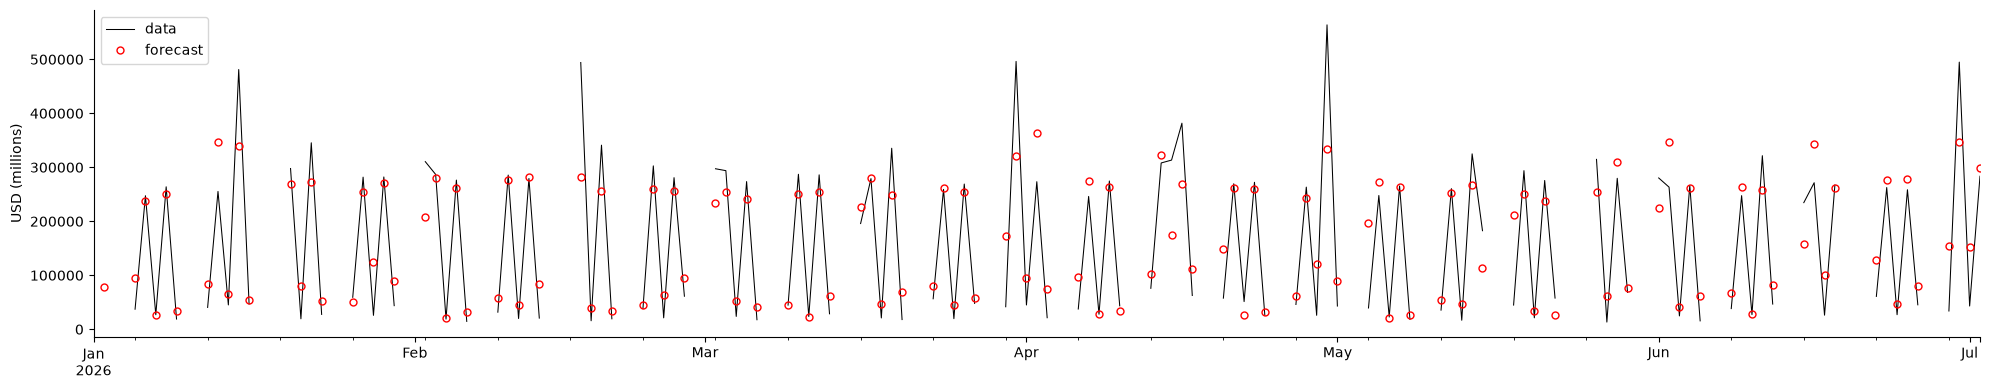

In [10]:
# prepare data for plot
year_df = series.to_dataframe()
year_df = year_df[year_df.index.year == 2026]
year_ts = TimeSeries.from_dataframe(year_df)
obs = ~np.isnan(year_ts.values()).flatten()
xx = df_forecast.index[obs]
yy = df_forecast.FLOW.values[obs]

# plot a chart
plt.figure(figsize=(20,4))
year_ts.plot(color='k', linewidth=.75, label='data')
plt.plot(xx, yy, 'or', markersize=5, mfc='none', label='forecast')
plt.ylabel('USD (millions)', fontweight='normal')
plt.legend()
plt.xlabel(None)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Construct future covariates

In [11]:
threshold = 250000
tau = scaler.transform(TimeSeries.from_values([threshold])).values()[0][0]

date_index = series_scaled.time_index
values = series_scaled.univariate_values()

df_vf = pd.DataFrame({
    'DATE': pd.to_datetime(date_index).normalize(),
    'FLOW': values
})

df_vf['FUTURE_VALUE'] = 0.0
df_vf.loc[df_vf.FLOW>tau, 'FUTURE_VALUE'] = df_vf[df_vf.FLOW>tau].FLOW.values * (1 + .2 * np.random.choice([-1,1], size=sum(df_vf.FLOW>tau)) * np.random.rand(sum(df_vf.FLOW>tau)))
df_vf['NOFLOW'] = ((df_vf['DATE'].dt.dayofweek >= 5) & (df_vf.FLOW.isnull())).astype(int)
cov_full = darts.TimeSeries.from_dataframe(df_vf, 'DATE', ['FUTURE_VALUE', 'NOFLOW'], fill_missing_dates=False, freq='D')
cov_train, cov_test = cov_full.split_before(split_point_val)


## Plot extreme values versus future covariates

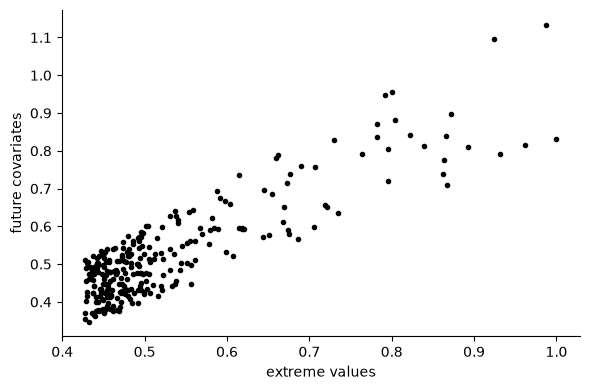

In [12]:
plt.figure(figsize=(6,4))
plt.plot(df_vf.FLOW.values[df_vf.FLOW.values>tau], df_vf.FUTURE_VALUE.values[df_vf.FLOW.values>tau], '.k')
plt.xlabel('extreme values')
plt.ylabel('future covariates')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## Fine tuning with future covariates

In [13]:
SEED = 0
limits = {"lags_lb": 1, "lags_ub": 360, "max_depth_lb": 3, "max_depth_ub": 9, "n_estimators_lb": 10, "n_estimators_ub": 100, "learning_rate_lb": 0.001, "learning_rate_ub": 0.5, "min_child_weight_lb": 1.0, "min_child_weight_ub": 10.0, "subsample_lb": 0.5, "subsample_ub": 1.0, "colsample_bytree_lb": 0.5, "colsample_bytree_ub": 1.0, "gamma_lb": 0.0, "gamma_ub": 5.0, "n_trials": 25}

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    multivariate=True,
    group=True,
    n_startup_trials=50,
)

def objective(trial):
    lags = trial.suggest_int("lags", limits["lags_lb"], limits["lags_ub"])
    max_depth = trial.suggest_int("max_depth", limits["max_depth_lb"], limits["max_depth_ub"])
    n_estimators = trial.suggest_int("n_estimators", limits["n_estimators_lb"], limits["n_estimators_ub"])
    learning_rate = trial.suggest_float(
        "learning_rate",
        limits["learning_rate_lb"],
        limits["learning_rate_ub"],
        log=True,
    )

    min_child_weight = trial.suggest_float(
        "min_child_weight",
        limits["min_child_weight_lb"],
        limits["min_child_weight_ub"],
    )
    subsample = trial.suggest_float(
        "subsample",
        limits["subsample_lb"],
        limits["subsample_ub"],
    )
    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        limits["colsample_bytree_lb"],
        limits["colsample_bytree_ub"],
    )
    gamma = trial.suggest_float(
        "gamma",
        limits["gamma_lb"],
        limits["gamma_ub"],
    )

    model = XGBModel(
        random_state=SEED,
        lags=lags,
        lags_future_covariates=[0],
        max_depth=max_depth,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        output_chunk_length=1,
        model_kwargs={
            "min_child_weight": min_child_weight,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "gamma": gamma,
        },
    )

    model.fit(
        train_val,
        val_series=test_val,
        future_covariates=cov_train,
        val_future_covariates=cov_test,
        verbose=False,
    )

    pred = model.predict(n=len(test_val), future_covariates=cov_full)

    error = rmse(
        scaler.inverse_transform(test_val),
        scaler.inverse_transform(pred),
    )

    return error


optuna.logging.set_verbosity(optuna.logging.WARNING) # do not print progress (comment to see progress messages)

# run the hyperparameter search algorithm
study = optuna.create_study(direction="minimize", sampler=sampler) # create the object that will explore the hyperparameters
study.optimize(objective, n_trials=limits['n_trials']) # run fine tuning
optimal_pars = study.best_params # save best hyperparameters dictionary

print('Fine tuning with future covariates is done.')


Fine tuning with future covariates is done.


## Training with future covariates

In [14]:
date_cut = '2026-01-01'
target_date = pd.Timestamp(date_cut)
split_index = series.time_index.get_loc(target_date)
split_point = series_scaled.time_index[split_index]
train, test = series_scaled.split_before(split_point)

model = XGBModel(
    random_state=SEED,
    lags=optimal_pars['lags'],
    lags_future_covariates=[0],
    max_depth=optimal_pars['max_depth'],
    n_estimators=optimal_pars['n_estimators'],
    learning_rate=optimal_pars['learning_rate'],
    likelihood='quantile', # add for uncertainty quantification
    quantiles=[0.05, 0.5, 0.95], # add for uncertainty quantification
    model_kwargs={
        "min_child_weight": optimal_pars['min_child_weight'],
        "subsample": optimal_pars['subsample'],
        "colsample_bytree": optimal_pars['colsample_bytree'],
        "gamma": optimal_pars['gamma'],
    },
)


model.fit(train, future_covariates=cov_full)
forecast = model.predict(n=len(test), future_covariates=cov_full)
df_forecast = scaler.inverse_transform(forecast).to_dataframe()


print('Model has been trained with future covariates. Forecast is ready!')


Model has been trained with future covariates. Forecast is ready!


## Plot forecast with future covariates

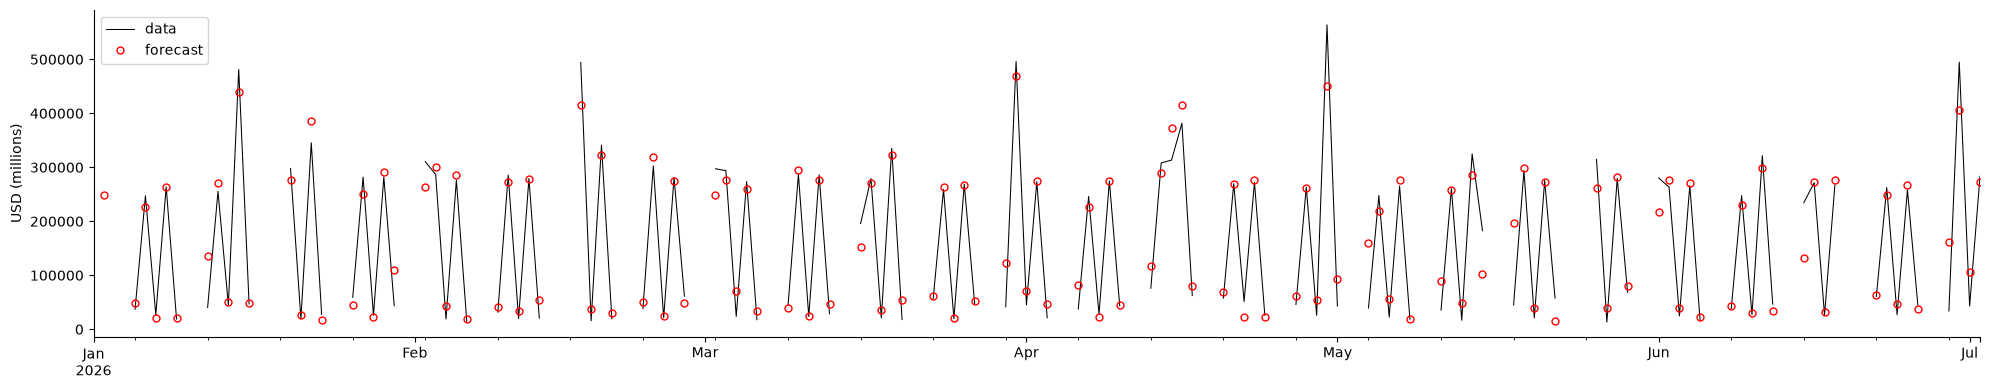

In [15]:
# prepare data for plot
year_df = series.to_dataframe()
year_df = year_df[year_df.index.year == 2026]
year_ts = TimeSeries.from_dataframe(year_df)
obs = ~np.isnan(year_ts.values()).flatten()
xx = df_forecast.index[obs]
yy = df_forecast.FLOW.values[obs]

# plot a chart
plt.figure(figsize=(20,4))
year_ts.plot(color='k', linewidth=.75, label='data')
plt.plot(xx, yy, 'or', markersize=5, mfc='none', label='forecast')
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()


## Uncertainty and prediction intervals

In [16]:
forecast_u = model.predict(n=len(test), future_covariates=cov_full, num_samples=1000)
forecast_u = scaler.inverse_transform(forecast_u)
q05 = forecast_u.quantile(.05)
q95 = forecast_u.quantile(.95)


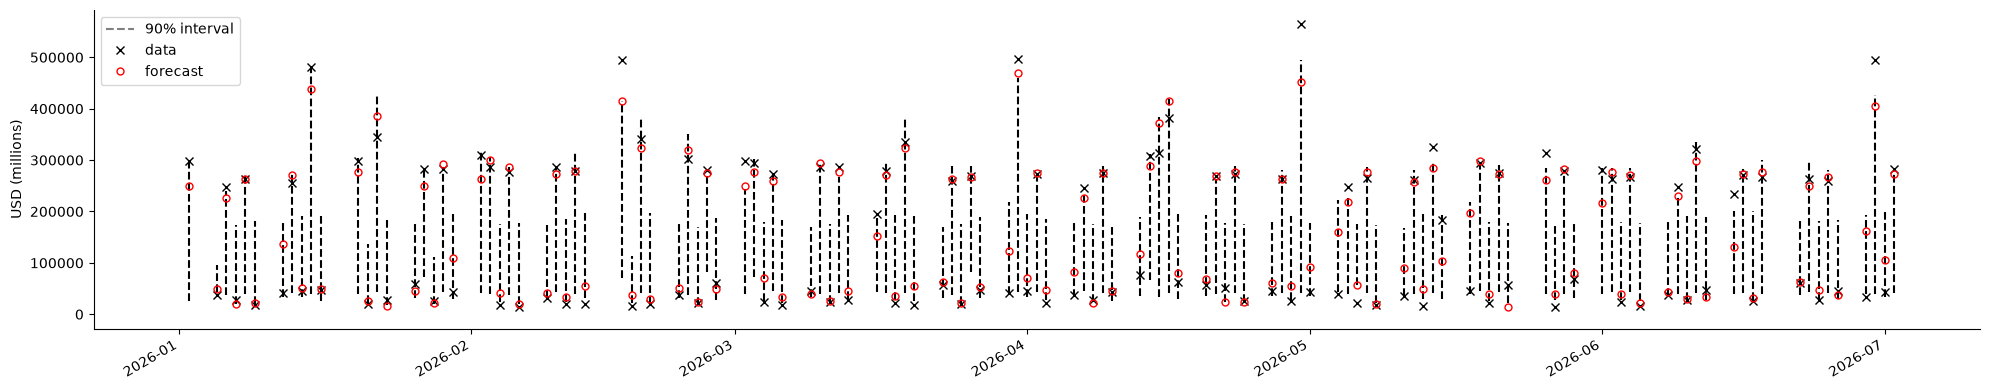

In [17]:
# prepare data for plot
year_df = series.to_dataframe()
year_df = year_df[year_df.index.year == 2026]
year_ts = TimeSeries.from_dataframe(year_df)
obs = ~np.isnan(year_ts.values()).flatten()
xx = df_forecast.index[obs]
yy = df_forecast.FLOW.values[obs]
int_low = q05.values().flatten()
int_up = q95.values().flatten()


plt.figure(figsize=(20, 4))
interval_lines = plt.vlines(df_forecast.index, -1, -1, colors='grey', linewidth=1.5, linestyle='--', zorder=1, label='90% interval') # dummy line just for the legend
for i, t in enumerate(df_forecast.index):
    if obs[i]:
        plt.plot(
            [t, t],                 
            [int_low[i], int_up[i]],
            color='k',
            linewidth=1.5,
            solid_capstyle='butt',
            linestyle='--',
        )

year_ts.plot(color='k', marker='x', linewidth=0., label='data')
plt.plot(xx, yy, 'or', markersize=5, mfc='none', label='forecast')
plt.ylabel('USD (millions)', fontweight='normal')
plt.xlabel(None)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()
